In [1]:
import pandas as pd

df_true = pd.read_csv("../data/processed/true_ipd_trial_001.csv")
ipd_ours = pd.read_csv("../data/processed/reconstructed_ipd_ours_trial_001.csv")
ipd_resolve = pd.read_csv("../data/processed/reconstructed_ipd_resolve_trial_001.csv")

# Reconstruction Validation

This notebook evaluates the accuracy of IPD reconstruction methods.

We compare:
- true IPD
- our reconstruction
- RESOLVE-IPD reconstruction

Evaluation is based on:
- Kaplan–Meier curve agreement
- survival differences at fixed times
- reconstruction diagnostics

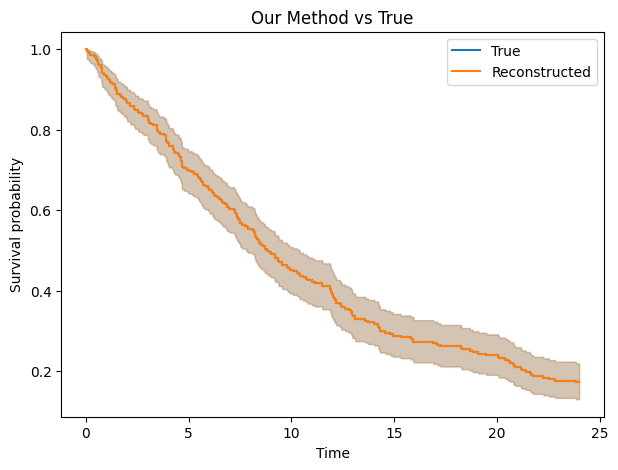

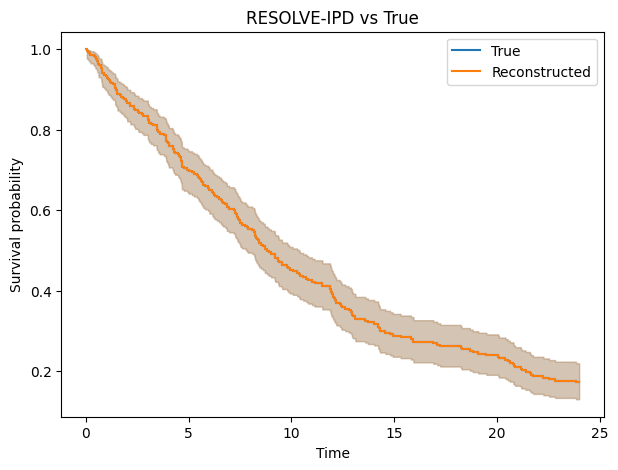

In [2]:
from src.validation.plots import plot_km_comparison
import matplotlib.pyplot as plt

fig1, _ = plot_km_comparison(df_true, ipd_ours, title="Our Method vs True")
plt.show()
fig2, _ = plot_km_comparison(df_true, ipd_resolve, title="RESOLVE-IPD vs True")
plt.show()

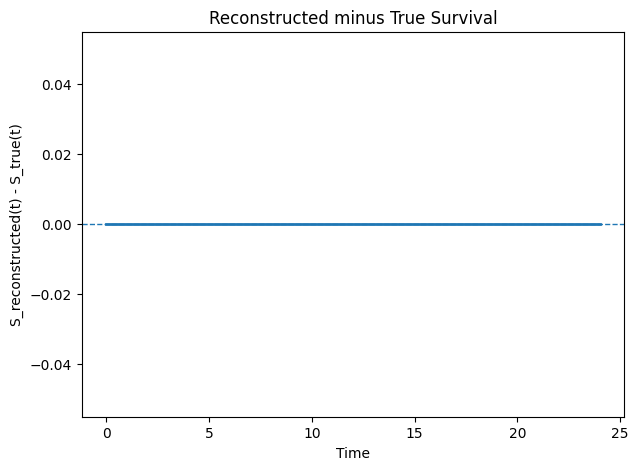

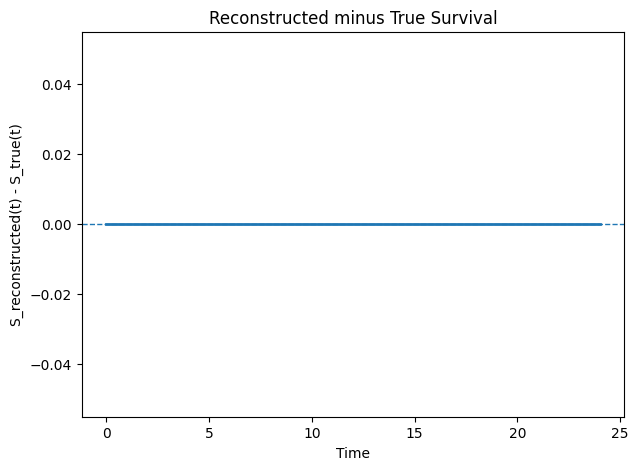

In [3]:
from src.validation.plots import plot_survival_difference_curve

fig, _ = plot_survival_difference_curve(df_true, ipd_ours)
plt.show()

fig, _ = plot_survival_difference_curve(df_true, ipd_resolve)
plt.show()

In [4]:
from src.validation.metrics import summary_metrics

metrics_ours = summary_metrics(df_true, ipd_ours, t0=10)
metrics_resolve = summary_metrics(df_true, ipd_resolve, t0=10)

import pandas as pd

pd.DataFrame([
    {"method": "ours", **metrics_ours},
    {"method": "resolve_ipd", **metrics_resolve},
])

,method,km_rmse,survival_diff_t0,n_true,n_recon
0,ours,0.0,0.0,300,300
1,resolve_ipd,0.0,0.0,300,300


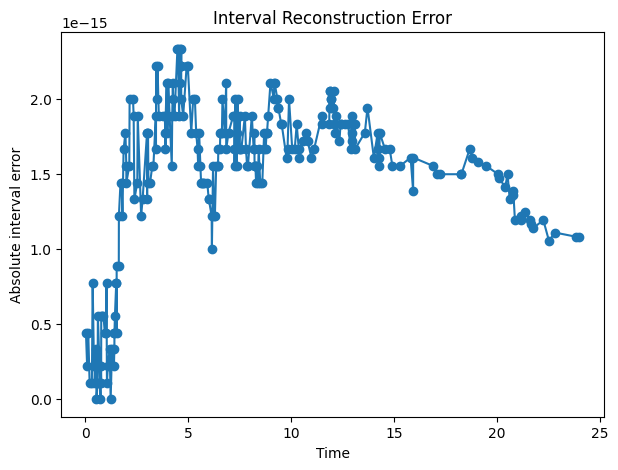

In [5]:
event_table_ours = pd.read_csv("../data/processed/reconstruction_event_table_ours_trial_001.csv")

from src.validation.plots import plot_interval_error

fig, _ = plot_interval_error(event_table_ours)
plt.show()

## Reconstruction Accuracy and Validation

The reconstructed Kaplan–Meier curves from both our method and the RESOLVE-IPD implementation are visually indistinguishable from the true survival curve across the entire time horizon. The overlaid plots show complete alignment, with no observable deviation between reconstructed and true trajectories.

This is further confirmed by the difference curves, where 
$$
S_{\text{reconstructed}}(t) - S_{\text{true}}(t)
$$
is identically zero across all time points. Quantitatively, both methods achieve:
- KM RMSE = 0  
- zero error in survival probability at the evaluation time $t_0$  
- exact recovery of sample size ($n=300$)

The interval-level reconstruction diagnostics show errors on the order of $10^{-15}$, indicating that any discrepancies are purely due to numerical precision rather than methodological error.

Overall, these results demonstrate that, under ideal conditions with fully observed KM inputs and censoring information, both reconstruction methods recover the underlying IPD exactly. This validates the correctness of the reconstruction pipeline and confirms that subsequent analysis can treat reconstructed IPD as effectively equivalent to the true data in this setting.